In [14]:
import numpy as np
import random
import itertools
from vllm import LLM, SamplingParams
from transformers import AutoTokenizer
from datasets import load_dataset
import sys
import os
from drift import get_training_matrix, l1_solve
import torch
import json
import matplotlib.pyplot as plt
from attribute_prompts import base_prompt
import cvxpy as cp

In [2]:
selected_prompts = [
    "You are an AI assistant that speaks like a pirate.",
    "You are an AI assistant that speaks like a cowboy.",
    "You are an AI assistant that speaks in internet slang.",
    "You are an AI assistant that speaks like a robot.",
    "You are an AI assistant that speaks like a university professor."
]

In [7]:
with open("../data/toy/attribute/user1_train.json", "r") as f:
    data = json.load(f)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# Model setup
model_id = "meta-llama/Llama-3.2-1B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)

llm = LLM(
    model=model_id,
    tensor_parallel_size=1,
    gpu_memory_utilization=0.7,
    max_model_len=16384
)

INFO 07-30 11:55:24 [config.py:841] This model supports multiple tasks: {'classify', 'reward', 'embed', 'generate'}. Defaulting to 'generate'.
INFO 07-30 11:55:24 [config.py:1472] Using max model len 16384
INFO 07-30 11:55:30 [config.py:2285] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 07-30 11:55:32 [core.py:526] Waiting for init message from front-end.
INFO 07-30 11:55:32 [core.py:69] Initializing a V1 LLM engine (v0.9.2) with config: model='meta-llama/Llama-3.2-1B-Instruct', speculative_config=None, tokenizer='meta-llama/Llama-3.2-1B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config={}, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=16384, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto,  device_config=cuda, decoding_config=DecodingConfig(backend='a

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


INFO 07-30 11:55:52 [default_loader.py:272] Loading weights took 3.63 seconds
INFO 07-30 11:55:53 [gpu_model_runner.py:1801] Model loading took 2.3185 GiB and 6.757453 seconds
INFO 07-30 11:56:44 [backends.py:508] Using cache directory: /mmfs1/home/devinl6/.cache/vllm/torch_compile_cache/d386c4a692/rank_0_0/backbone for vLLM's torch.compile
INFO 07-30 11:56:44 [backends.py:519] Dynamo bytecode transform time: 51.48 s
INFO 07-30 11:56:47 [backends.py:155] Directly load the compiled graph(s) for shape None from the cache, took 2.562 s
INFO 07-30 11:56:49 [monitor.py:34] torch.compile takes 51.48 s in total
INFO 07-30 11:56:51 [gpu_worker.py:232] Available KV cache memory: 27.49 GiB
INFO 07-30 11:56:52 [kv_cache_utils.py:716] GPU KV cache size: 900,752 tokens
INFO 07-30 11:56:52 [kv_cache_utils.py:720] Maximum concurrency for 16,384 tokens per request: 54.98x


Capturing CUDA graph shapes: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 67/67 [00:26<00:00,  2.57it/s]


INFO 07-30 11:57:18 [gpu_model_runner.py:2326] Graph capturing finished in 26 secs, took 0.31 GiB
INFO 07-30 11:57:18 [core.py:172] init engine (profile, create kv cache, warmup model) took 85.13 seconds


In [8]:
data = [
    (item["prompt"], item["chosen"], item["rejected"]) 
    for item in data
]

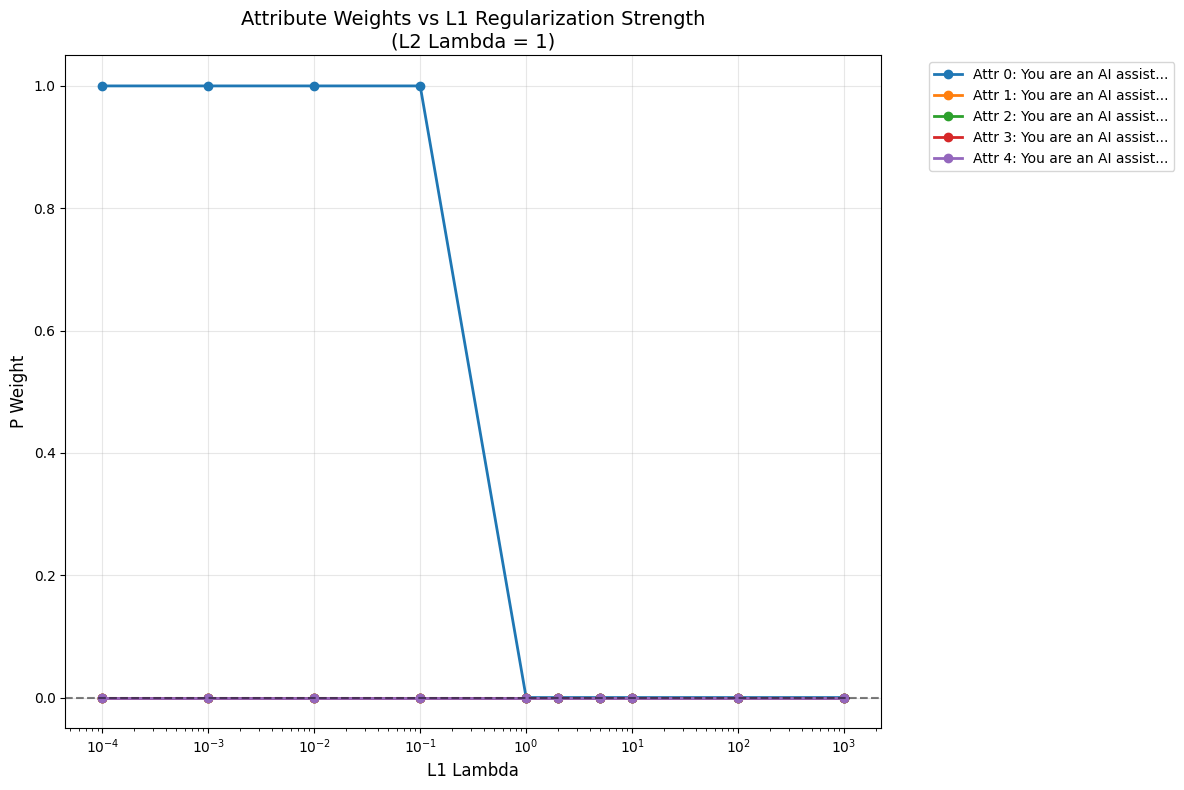

In [16]:
d = get_training_matrix(data, llm, tokenizer, base_prompt, selected_prompts, device)

d_mean = torch.mean(d, dim=0).cpu().numpy()

lambdas = [0.0001, 0.001, 0.01, 0.1, 1, 2, 5, 10, 100, 1000]

p_list = []
found = False
for l1_lambda in lambdas:
    p_var = cp.Variable(len(d_mean))
    constraints = [cp.norm1(p_var) <= 1]
    
    objective = cp.Maximize(d_mean @ p_var - l1_lambda * cp.norm1(p_var))
    problem = cp.Problem(objective, constraints)
    
    problem.solve()
    p = p_var.value
    if sum(p <= 1e-5) == len(selected_prompts) - 2 and not found:
        found = True
        print(p / np.linalg.norm(p, ord=1))
    p_list.append(p)

p_array = np.array(p_list)  # Shape: (num_lambdas, num_attributes)

# Create the plot
plt.figure(figsize=(12, 8))

# Plot each attribute's weight as a function of lambda
for i in range(len(selected_prompts)):
    plt.plot(lambdas, p_array[:, i], 'o-', linewidth=2, markersize=6, 
             label=f'Attr {i}: {selected_prompts[i][:20]}...')

plt.xlabel('L1 Lambda', fontsize=12)
plt.ylabel('P Weight', fontsize=12)
plt.title('Attribute Weights vs L1 Regularization Strength\n(L2 Lambda = 1)', fontsize=14)
plt.xscale('log')  # Log scale for lambda since values span orders of magnitude
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()

# Add horizontal line at y=0 for reference
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.show()

[6.74375816e-01 3.25624156e-01 1.74896088e-08 3.45192602e-09
 7.43549329e-09]


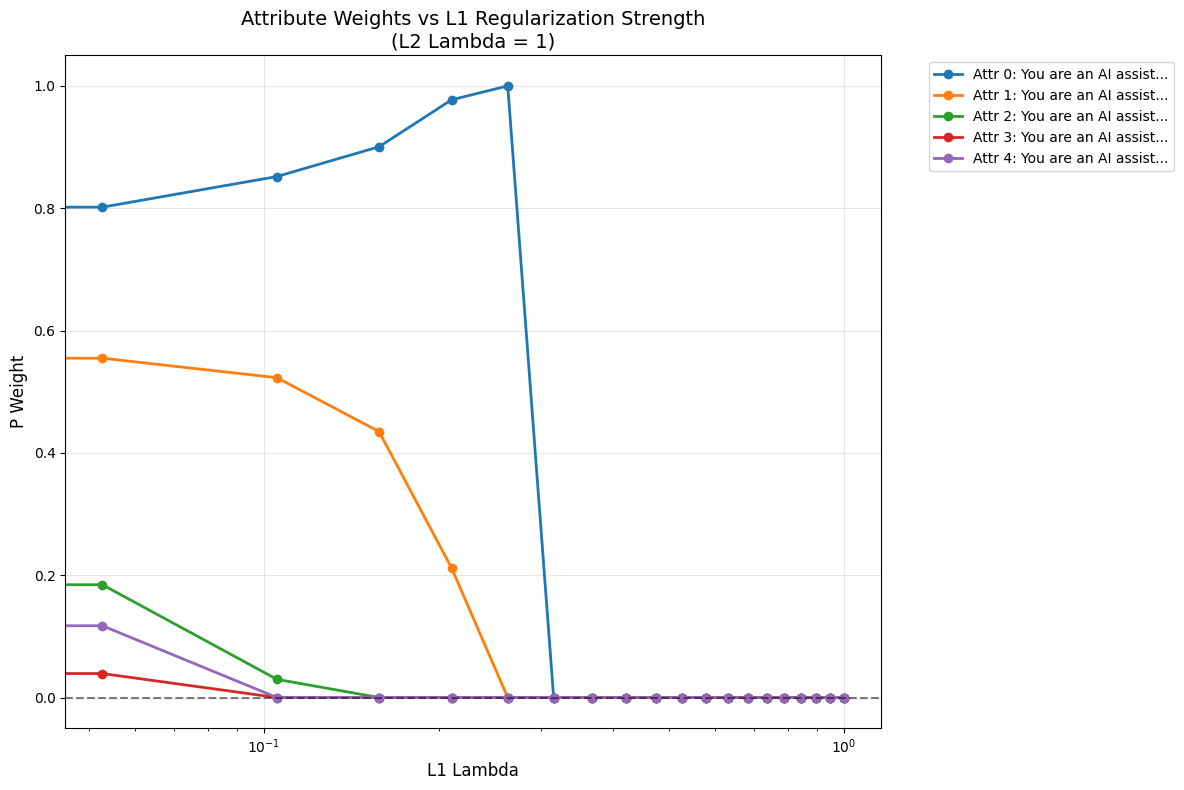

In [11]:
lambdas = np.linspace(0, 1, 20)

p_list = []
found = False
for l1_lambda in lambdas:
    p = l1_solve(d_mean, l1_lambda)
    if sum(p <= 1e-5) == len(selected_prompts) - 2 and not found:
        found = True
        print(p / np.linalg.norm(p, ord=1))
    p_list.append(p)

p_array = np.array(p_list)  # Shape: (num_lambdas, num_attributes)

# Create the plot
plt.figure(figsize=(12, 8))

# Plot each attribute's weight as a function of lambda
for i in range(len(selected_prompts)):
    plt.plot(lambdas, p_array[:, i], 'o-', linewidth=2, markersize=6, 
             label=f'Attr {i}: {selected_prompts[i][:20]}...')

plt.xlabel('L1 Lambda', fontsize=12)
plt.ylabel('P Weight', fontsize=12)
plt.title('Attribute Weights vs L1 Regularization Strength\n(L2 Lambda = 1)', fontsize=14)
plt.xscale('log')  # Log scale for lambda since values span orders of magnitude
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()

# Add horizontal line at y=0 for reference
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.savefig('../results/plots/weight_recovery/attributes.png', dpi=300, bbox_inches='tight')

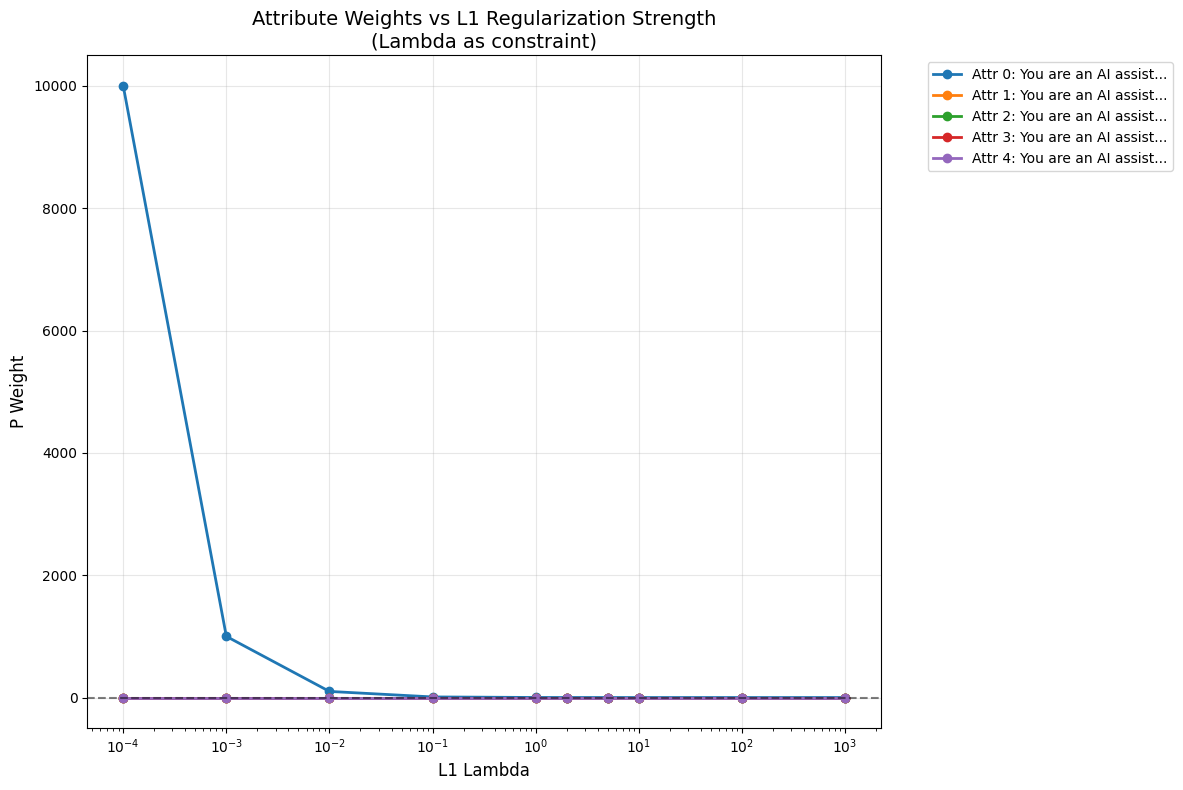

In [19]:
lambdas = [0.0001, 0.001, 0.01, 0.1, 1, 2, 5, 10, 100, 1000]

p_list = []
found = False
for l1_lambda in lambdas:
    p_var = cp.Variable(len(d_mean))
    constraints = [cp.norm1(p_var) <= 1 / (l1_lambda + 1e-10)]
    
    objective = cp.Maximize(d_mean @ p_var)
    problem = cp.Problem(objective, constraints)
    
    problem.solve()
    p = p_var.value
    if sum(p <= 1e-5) == len(selected_prompts) - 2 and not found:
        found = True
        print(p / np.linalg.norm(p, ord=1))
    p_list.append(p)

p_array = np.array(p_list)  # Shape: (num_lambdas, num_attributes)

# Create the plot
plt.figure(figsize=(12, 8))

# Plot each attribute's weight as a function of lambda
for i in range(len(selected_prompts)):
    plt.plot(lambdas, p_array[:, i], 'o-', linewidth=2, markersize=6, 
             label=f'Attr {i}: {selected_prompts[i][:20]}...')

plt.xlabel('L1 Lambda', fontsize=12)
plt.ylabel('P Weight', fontsize=12)
plt.title('Attribute Weights vs L1 Regularization Strength\n(Lambda as constraint)', fontsize=14)
plt.xscale('log')  # Log scale for lambda since values span orders of magnitude
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()

# Add horizontal line at y=0 for reference
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.show()